In [17]:
using Revise
using ConjugateHeatTransfer
using CairoMakie
using LinearAlgebra
using QuadGK
using PolygonOps
using StaticArrays

In [18]:
# Parameters
N_bie = 32; # number of points per slit for BIE
solve_quad(args...) = quadgk(args...; atol=1e-10, rtol=1e-10)[1];
plot_quad(args...) = quadgk(args...; atol=1e-5, rtol=1e-5)[1];

# Bodies
zc1 = -2;
shape1(θ) = exp(im*θ) * (1 + 0.3*cos(2*θ-1) + 0.1*sin(5*θ));
temp1(θ) = (1 + 0.3*cos(2*θ-1) + 0.1*sin(5*θ));
b1 = DirichletBody(zc1, θ->zc1+shape1(θ), θ->temp1(θ));

zc2 = 2 - 2im;
shape2(θ) = exp(im*θ) * (1 + 0.2*sin(3*θ));
temp2(θ) = (0.75 + 0.2*sin(3*θ));
b2 = DirichletBody(zc2, θ->zc2+shape2(θ), θ->temp2(θ));

zc3 = 1 + 2im;
shape3(θ) = exp(im*θ);
temp3(θ) = 0.25;
b3 = DirichletBody(zc3, θ->zc3+shape3(θ), θ->temp3(θ));

bodies = [b1, b2, b3];

In [19]:
function solve_potential_flow(bodies)
    # Solve potential flow
    t0 = time();
    W = aaa_potential_flow(bodies, 64);
    println("Solved potential flow (", round(time()-t0, digits=3), " s)");
    t0 = time();
    reparametrize!(bodies, W; atol=1e-6);
    println("Joukowsky reparametrization done (", round(time()-t0, digits=3), " s)");
    return W
end

function solve_heat_transfer(bodies, Pe)
    # Panels
    panels = [DirichletPanel(body) for body in bodies];
    t0 = time();
    solve_densities!(panels, N_bie; Pe=Pe, atol=1e-6, quadrature=solve_quad);
    println("Densities solved (", round(time()-t0, digits=3), " s)");
    return panels
end

solve_heat_transfer (generic function with 1 method)

In [20]:
# Compute fluxes for a range of Peclet numbers
Pe_vec = collect(exp10.(LinRange(-6, 6, 13)));
fluxes = Vector{Vector{Float64}}();
W = solve_potential_flow(bodies);
for Pe in Pe_vec
    println("Solving for Pe = ", Pe)
    panels = solve_heat_transfer(bodies, Pe);
    push!(fluxes, [p.flux for p in panels])
    println([p.flux for p in panels])
end

flux_array = reduce(hcat, fluxes)
f1 = flux_array[1,:]
f2 = flux_array[2,:]
f3 = flux_array[3,:];

N samples: 32, AAA poles: 8
N samples: 64, AAA poles: 16
N samples: 128, AAA poles: 31
N samples: 256, AAA poles: 40
N samples: 512, AAA poles: 41
N samples: 1024, AAA poles: 39
N samples: 32, AAA poles: 7
N samples: 64, AAA poles: 16
N samples: 128, AAA poles: 25
N samples: 256, AAA poles: 26
N samples: 512, AAA poles: 26
N samples: 32, AAA poles: 1
N samples: 64, AAA poles: 1
  Q shape: (1548, 522)
  Fitting error: 1.9911849946652183e-13
Solved potential flow (2.829 s)
  w coeffs: 62
  dθ coeffs: 1061
  zη coeffs: 395
  Tη coeffs: 611
  w coeffs: 40
  dθ coeffs: 220
  zη coeffs: 143
  Tη coeffs: 184
  w coeffs: 30
  dθ coeffs: 24
  zη coeffs: 27
  Tη coeffs: 1
Joukowsky reparametrization done (1.045 s)
Solving for Pe = 1.0e-6
  g coeffs: 305
  g coeffs: 92
  g coeffs: 0
size(M) = (192, 96)
cond(M) = 1272.2458326788712
Densities solved (4.929 s)
[2.4081497744889955, 0.6035966517778114, -2.675486469678001]
Solving for Pe = 1.0e-5
  g coeffs: 305
  g coeffs: 92
  g coeffs: 0
size(M) = (

In [21]:
function evaluate_W(W, z)
    t0 = time();
    w = reshape(W(vec(z)), size(z));
    println("Flow evaluated (", round(time()-t0, digits=3), " s)");
    return w
end

function check_inside(body, z)
    poly = body.zθ.(LinRange(0, 2π, 100))
    poly[end] = poly[1]
    poly = [[real(z), imag(z)] for z in poly]
    return inpolygon([real(z), imag(z)], poly; in=true, on=false, out=false)
end

function evaluate_T(panels, w, Pe)
    bodies = [panel.body for panel in panels]
    # Mask interiors before evaluating temperature
    φ = real(w);
    ψ = imag(w);
    for body in bodies
        check_body(z) = check_inside(body, z)
        interior = check_body.(z)
        φ[interior] .= 0
        ψ[interior] .= 0
    end
    # Evaluate temperature
    t0 = time();
    T = EvaluateSystem(φ, ψ, panels; Pe=Pe, quadrature=plot_quad);
    println("Temperature evaluated (", round(time()-t0, digits=3), " s)");
    # Mask interiors
    for body in bodies
        check_body(z) = check_inside(body, z)
        interior = check_body.(z)
        φ[interior] .= NaN
        ψ[interior] .= body.ψ
        T[interior] .= NaN
    end
    return T
end

evaluate_T (generic function with 1 method)

In [25]:
# Evaluate T(z)
gridsize = 300
Lz = 6.1

x = collect(LinRange(-Lz, Lz, gridsize));
y = collect(LinRange(-Lz, Lz, gridsize));
z = x' .+ im*y;

Pe_plot = [1e-3, 1e3]

Pe = Pe_plot[1]
panels1 = solve_heat_transfer(bodies, Pe);
w1 = evaluate_W(W, z);
T1 = evaluate_T(panels1, w1, Pe);

Pe = Pe_plot[2]
panels2 = solve_heat_transfer(bodies, Pe);
w2 = evaluate_W(W, z);
T2 = evaluate_T(panels2, w2, Pe);

  g coeffs: 305
  g coeffs: 92
  g coeffs: 0
size(M) = (192, 96)
cond(M) = 630.0039128183166
Densities solved (4.577 s)
Flow evaluated (1.176 s)
Temperature evaluated (29.162 s)
  g coeffs: 305
  g coeffs: 92
  g coeffs: 0
size(M) = (192, 96)
cond(M) = 10.38814830833141
Densities solved (1.708 s)
Flow evaluated (0.895 s)
Temperature evaluated (4.219 s)


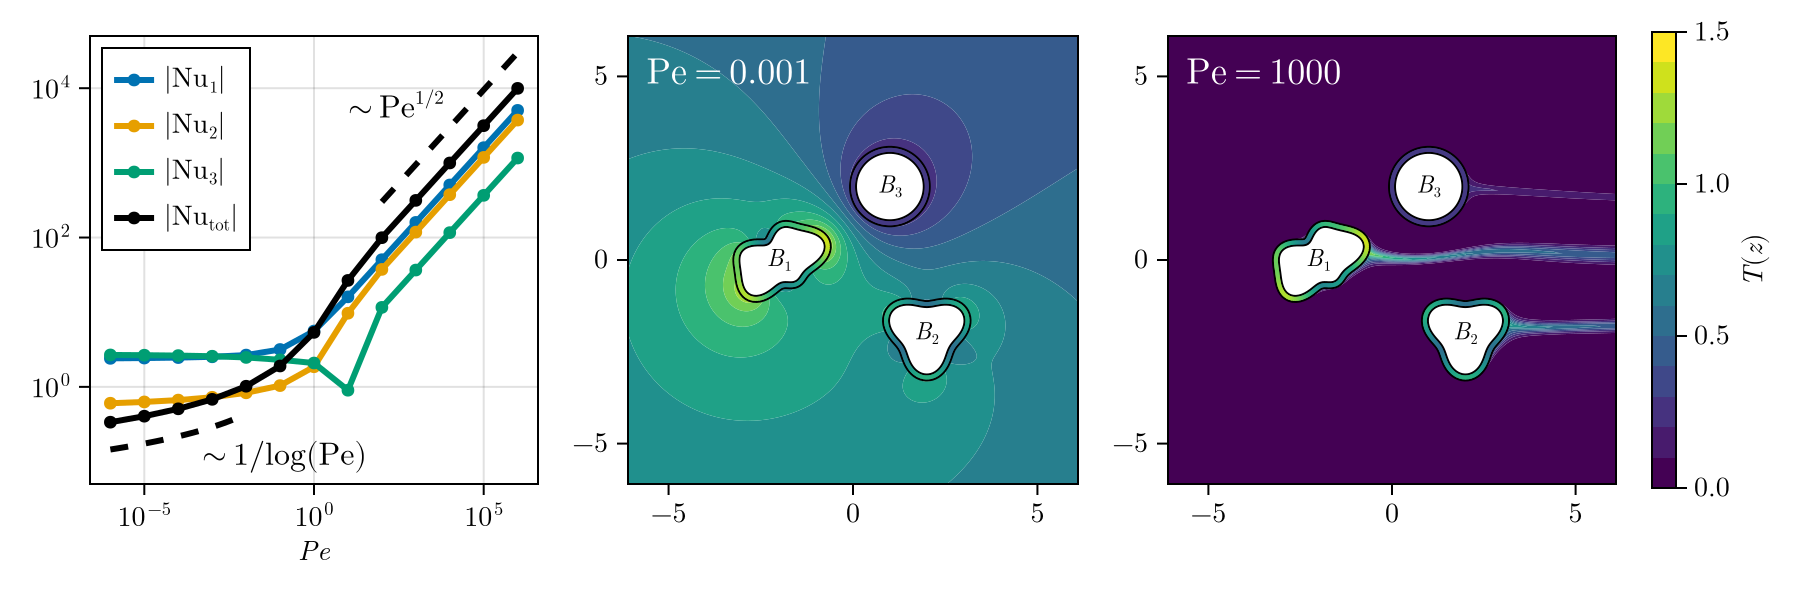

In [26]:
# Plot
fig = Figure(size=(900, 300));
set_theme!(theme_latexfonts());

# Levels
T_levels = LinRange(0, 1.5, 16);

# Left panel: fluxes
ax = Axis(fig[1,1], xscale=log10, yscale=log10, aspect=1);
line1 = scatterlines!(ax, Pe_vec, f1, linewidth=3, marker=:circle, label=L"|\mathrm{Nu}_1|");
line2 = scatterlines!(ax, Pe_vec, f2, linewidth=3, marker=:circle, label=L"|\mathrm{Nu}_2|");
line3 = scatterlines!(ax, Pe_vec, abs.(f3), linewidth=3, marker=:circle, label=L"|\mathrm{Nu}_3|");
line4 = scatterlines!(ax, Pe_vec, f1+f2+f3, linewidth=3, marker=:circle, color=:black, label=L"|\mathrm{Nu}_\mathrm{tot}|");

Pe_line = [1e2, 1e6]
lines!(ax, Pe_line, 30*Pe_line.^(1/2), linewidth=3, color=:black, linestyle=:dash)
text!(ax, L"\sim \mathrm{Pe}^{1/2}", position=(1e1, 1e4), align=(:left, :top), color=:black, fontsize=16)

Pe_line = 10 .^ LinRange(-6, -2, 31)
lines!(ax, Pe_line, -2 ./ log.(Pe_line), linewidth=3, color=:black, linestyle=:dash)
text!(ax, L"\sim 1/{\log(\mathrm{Pe})}", position=(5e-4, 2e-1), align=(:left, :top), color=:black, fontsize=16)

ylims!(ax, 5e-2, 5e4)
ax.xlabel = L"Pe"
axislegend(position=:lt)

# Plot temperature fields
for (i, (Pe_text, T, panels)) in enumerate([("0.001", T1, panels1), ("1000", T2, panels2)])
    ax = Axis(fig[1,1+i], aspect=DataAspect());
    xlims!(ax, -Lz, Lz)
    ylims!(ax, -Lz, Lz)
    #hidedecorations!(ax, grid=false)
    # Background for body interiors
    poly!(ax, [(-Lz, -Lz), (Lz, -Lz), (Lz, Lz), (-Lz, Lz)], color=:white, rasterize=true)
    # Temperature contours
    co = contourf!(ax, x, y, T', levels=T_levels, nan_color=:black);
    # Label with Peclet number
    text!(ax, L"\mathrm{Pe} = %$Pe_text", position=(-Lz+0.5, Lz-0.5), align=(:left, :top), color=:white, fontsize=18)
    # Bodies
    colorrange = (minimum(co._computed_levels.val), maximum(co._computed_levels.val));
    θp = LinRange(0, 2π, 100);
    for body in bodies
        boundary = body.zθ.(θp)
        temp = body.Tθ.(θp)
        lines!(ax, real(boundary), imag(boundary), color=:black, linewidth=4, colorrange=colorrange)
        lines!(ax, real(boundary), imag(boundary), color=temp, linewidth=2, colorrange=colorrange)
        # Replot with shift to get rid of color artifacts
        boundary = body.zθ.(θp.+π/100)
        temp = body.Tθ.(θp.+π/100)
        lines!(ax, real(boundary), imag(boundary), color=temp, linewidth=2, colorrange=colorrange)
    end
    # Colorbar
    if i == 2
        Colorbar(fig[1,4], co, label=L"$T(z)$");
    end
    # Body labels
    for (i, body) in enumerate(bodies)
        zc = body.zc
        text!(ax, L"$B_%$i$", position=(real(zc), imag(zc)), align=(:center, :center), color=:black, fontsize=12)
    end
end

save("fig_threebody_scaling.pdf", fig);
fig